In [128]:
!pip install lime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss
from tensorflow import keras
from tensorflow.keras import layers
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap
import warnings
warnings.filterwarnings("ignore")

In [129]:
df = pd.read_csv("email.csv")
df

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830.0,0.0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942.0,0.0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780.0,0.0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907.0,0.0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319.0,0.0,this kmh october holliswood number advised unu...
...,...,...,...,...,...,...,...,...,...,...,...
184069,{G3K7-C2HF04RQ-2640TMRF},02/03/2010 14:34:02,GCG0951,PC-4704,George.Cade.Chen@dtaa.com,NaN,NaN,Grant.Camden.Gay@dtaa.com,25334.0,0.0,objectified comparison however elevator blood ...
184070,{H3S3-O1NY22MG-6461PCRF},02/03/2010 14:34:03,BEC0505,PC-3375,XHW4327@netzero.com,NaN,NaN,BEC7@gmail.com,21345.0,0.0,99 organization it have northern defined repai...
184071,{S9P5-N2EB45RR-4677RCUP},02/03/2010 14:34:06,MHH0180,PC-9822,Olivia.Quynn.Hardy@dtaa.com;Cara_Rios@lockheed...,Penelope.Montana.Colon@dtaa.com;Sloane.Jade.Co...,Merrill.Hiram.Hess@dtaa.com,Merrill.Hiram.Hess@dtaa.com,42329.0,0.0,over forwarded commonwealth entire 1625 male a...
184072,{X0I7-S2PS91IB-5664LFUX},02/03/2010 14:34:12,BRS0734,PC-4785,Grady.Craig.Coffey@dtaa.com,Burke.Rooney.Stafford@dtaa.com,NaN,Burke.Rooney.Stafford@dtaa.com,41978.0,0.0,prince ankh prince prince ankh prince prince a...


In [130]:
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 0


In [131]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Fill missing vals
df.fillna('', inplace=True)

In [132]:
le = LabelEncoder()
for col in ['user', 'pc', 'to', 'cc', 'bcc', 'from']:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,588,553,17327,14629,0,1239,25830.0,0.0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,675,665,51112,0,0,1258,29942.0,0.0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,588,553,52620,0,0,1240,28780.0,0.0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,588,553,36164,0,0,1240,21907.0,0.0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,675,665,8354,0,442,1258,17319.0,0.0,this kmh october holliswood number advised unu...


In [133]:
# Feature Engineering from 'date'
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# feature selection
df.drop(columns=['date', 'to', 'cc', 'from'], inplace=True)


In [134]:
# Create a label based on 'bcc' and 'size' as suspicious
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df['size'] = df['size'].fillna(0)
df['is_malicious'] = ((df['bcc'].astype(str).astype(int) > 0) & (df['size'] > 50000)).astype(int)

print(df['is_malicious'].value_counts())

is_malicious
0    182863
1      1211
Name: count, dtype: int64


In [135]:
features = df.select_dtypes(include=['number', 'bool']).columns.tolist()
features.remove('is_malicious')

X = df[features]
y = df['is_malicious']

EDA

In [136]:
# Handle outliers using Z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).all(axis=1)  # Identify outliers (Z-score > 3)
print(f"Number of outlier rows: {outliers.sum()}")



Number of outlier rows: 0


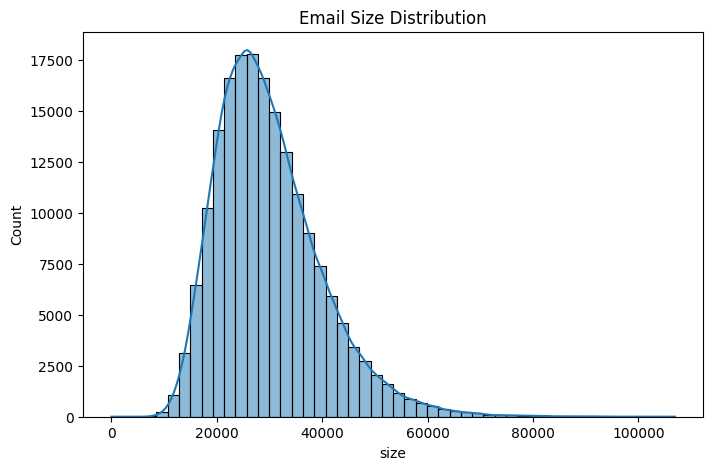

In [137]:
#size dist
plt.figure(figsize=(8,5))
sns.histplot(df['size'], bins=50, kde=True)
plt.title("Email Size Distribution")
plt.show()


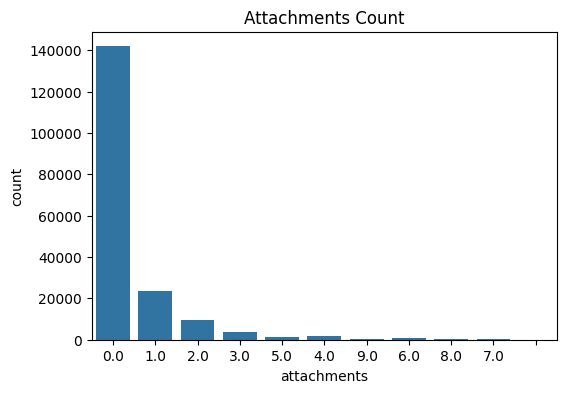

In [138]:
#Num ofattachments
plt.figure(figsize=(6,4))
sns.countplot(x='attachments', data=df)
plt.title("Attachments Count")
plt.show()


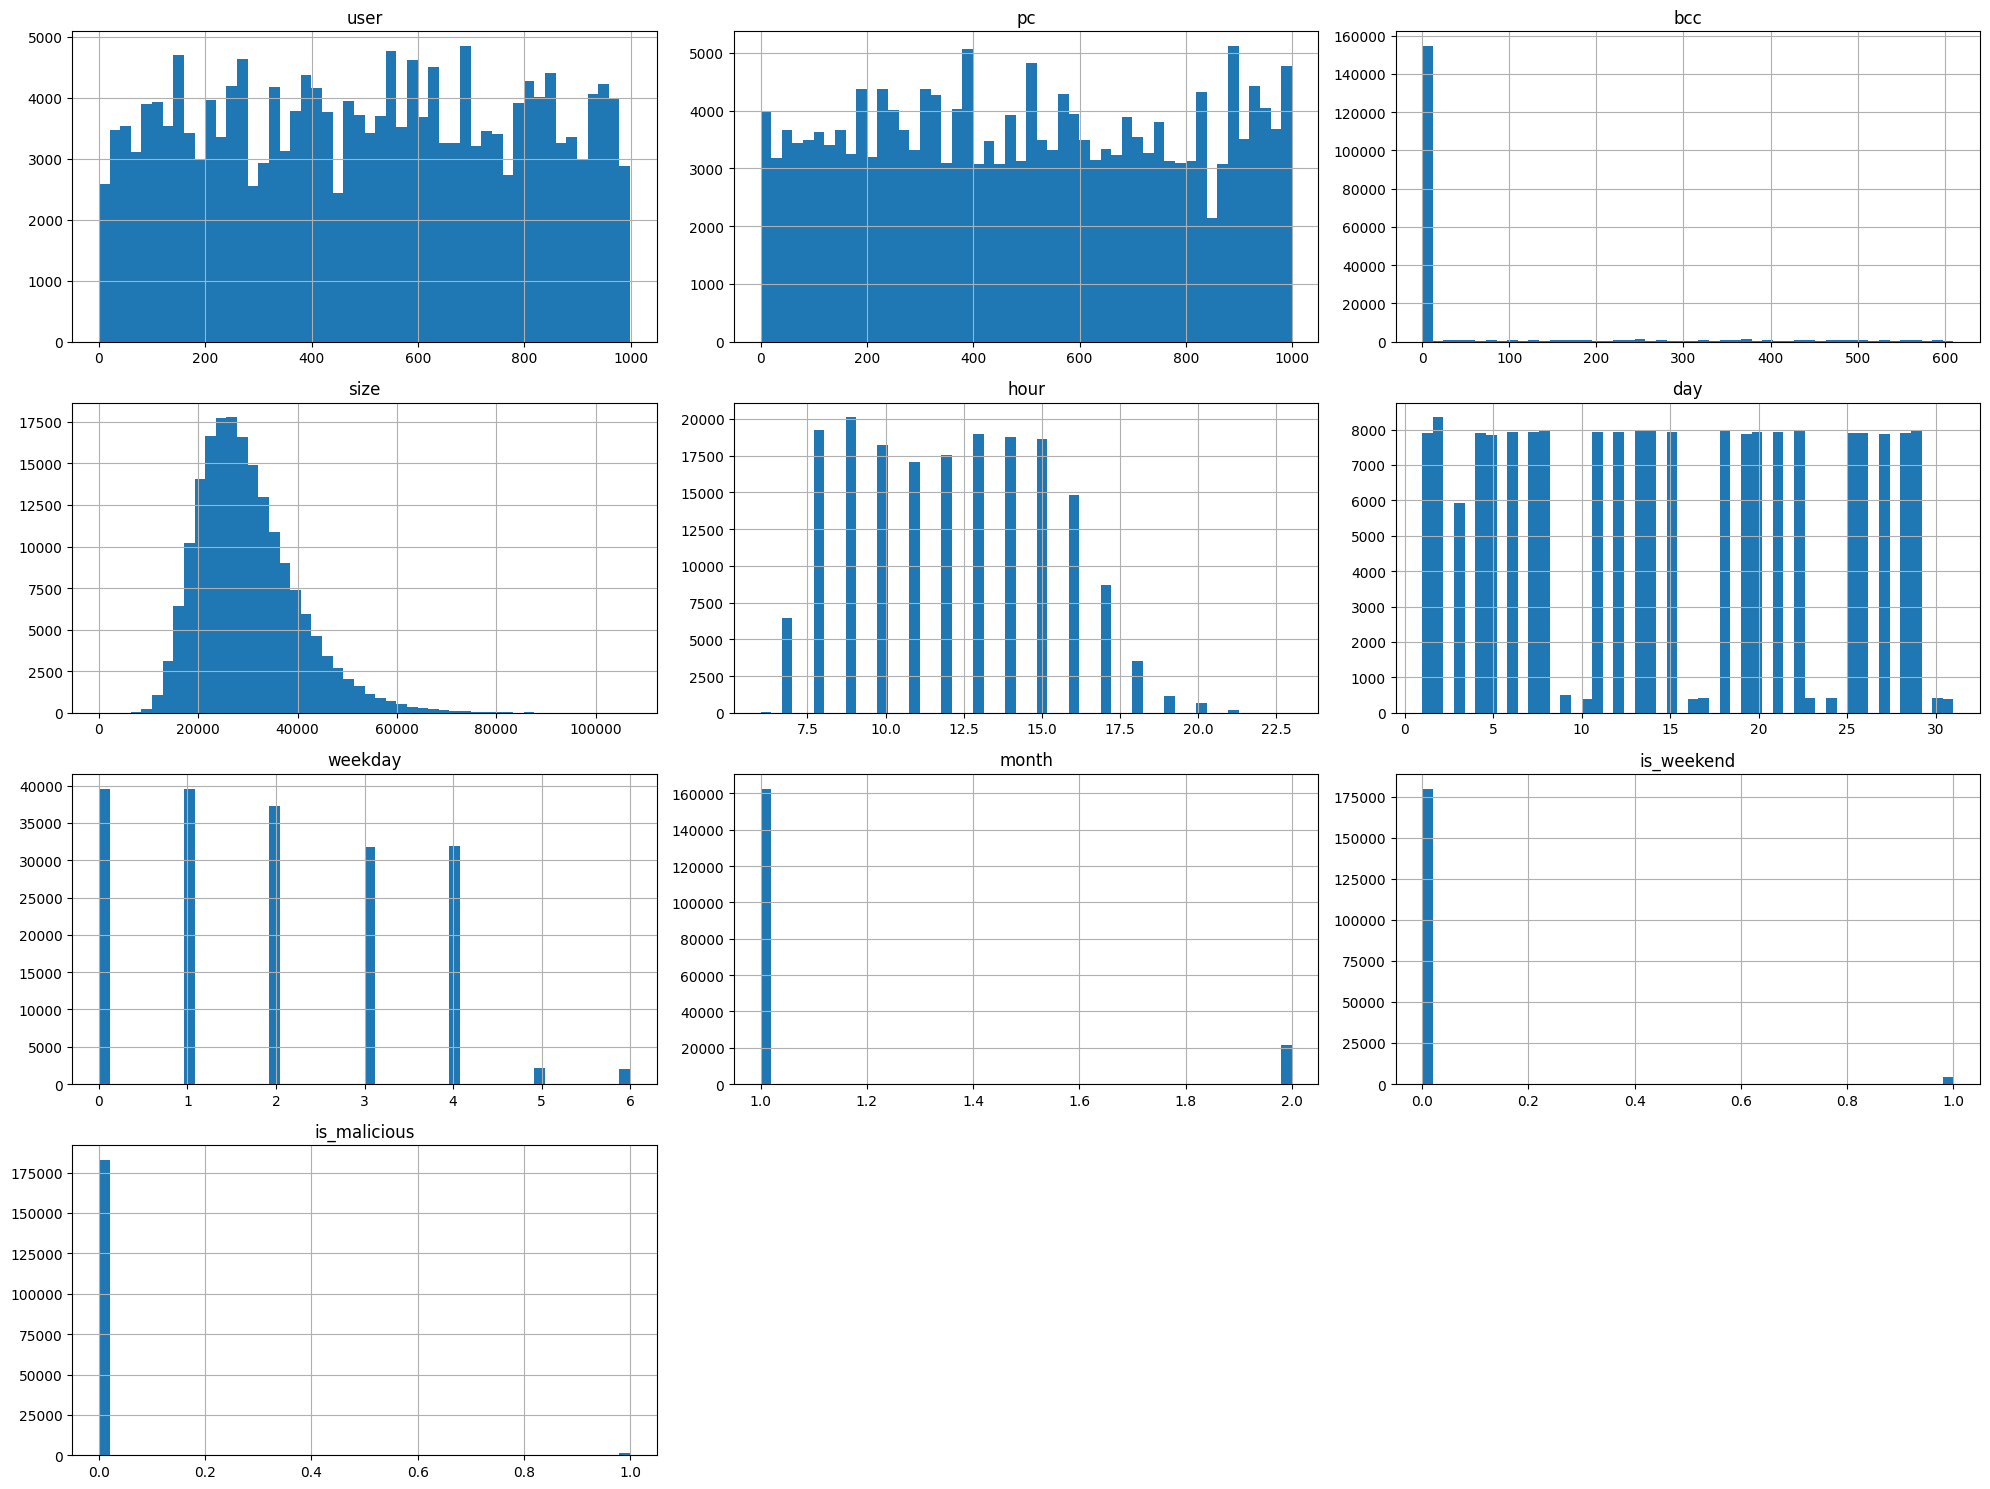

In [139]:
df.hist(figsize=(20, 15), bins=50)
plt.tight_layout()
plt.show()

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [141]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

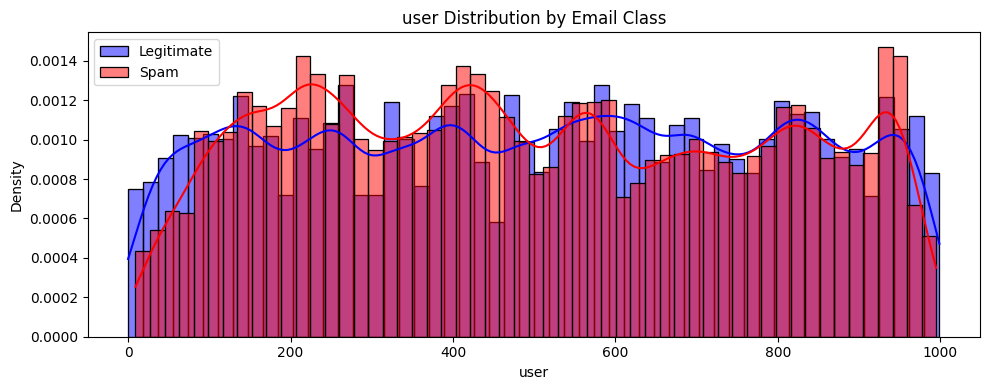

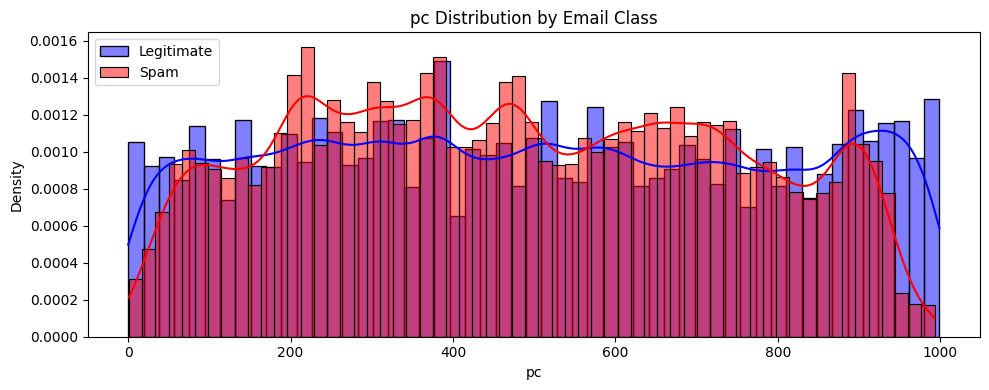

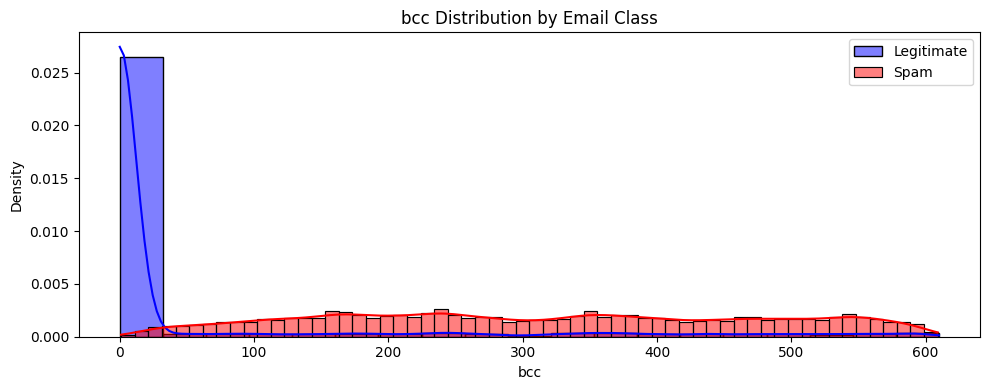

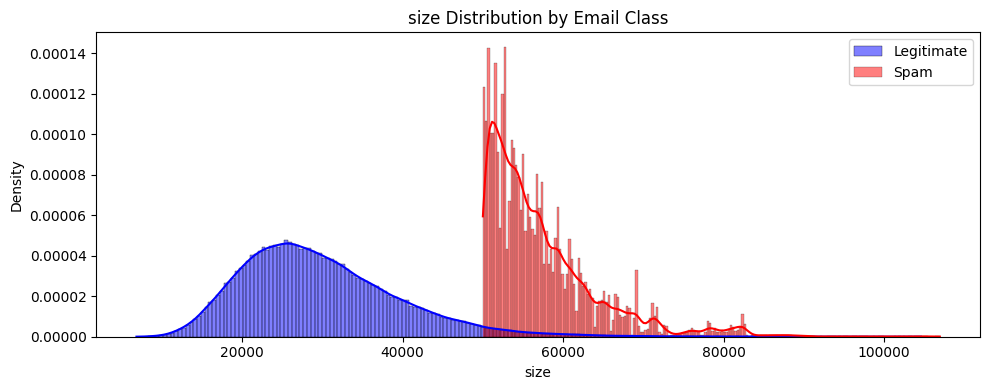

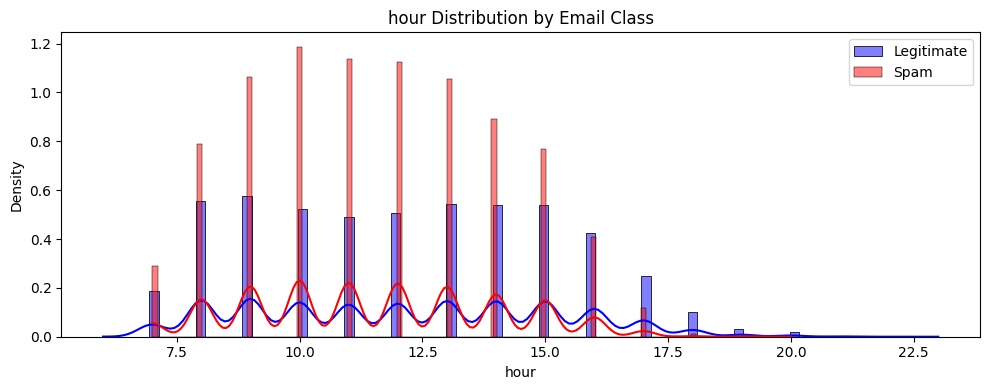

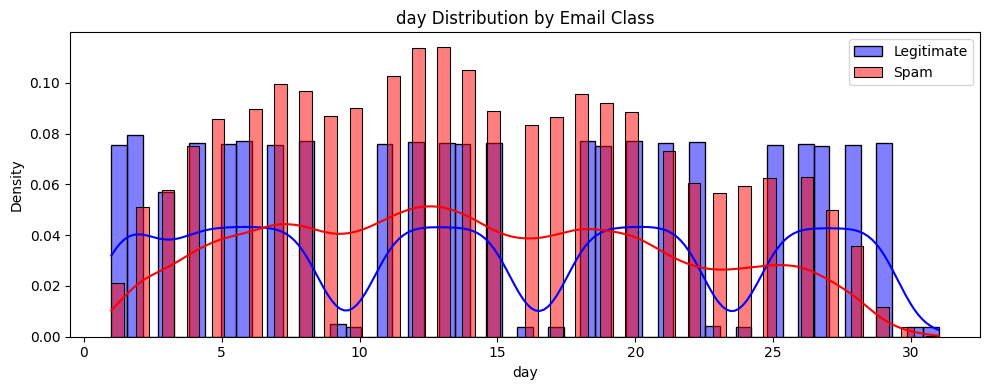

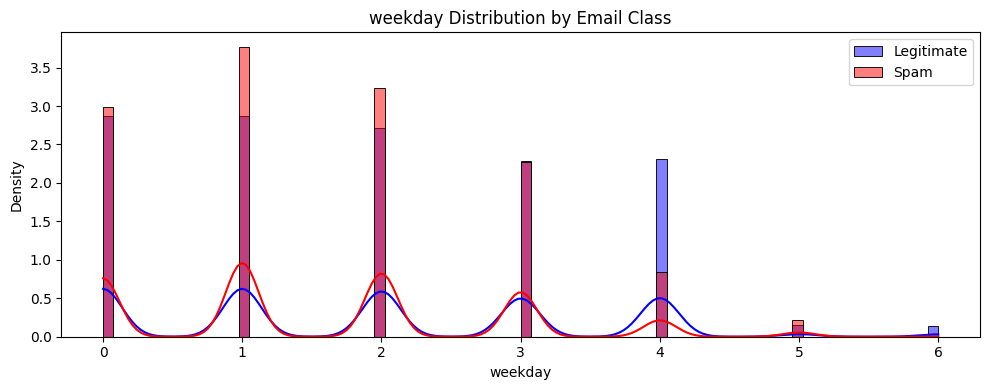

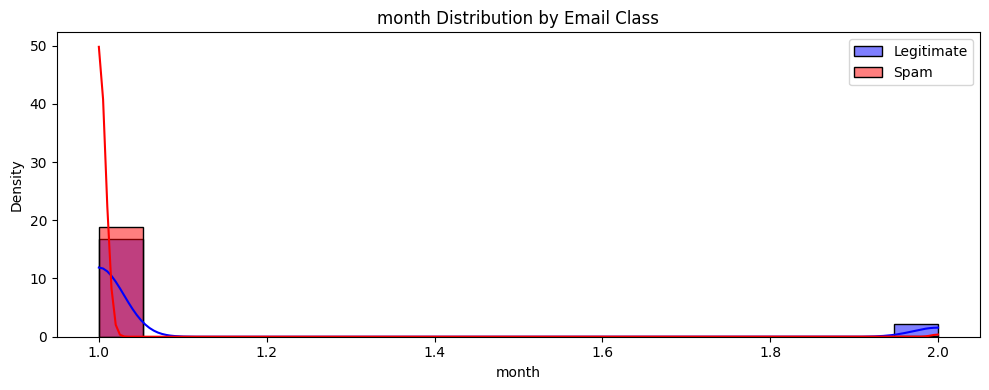

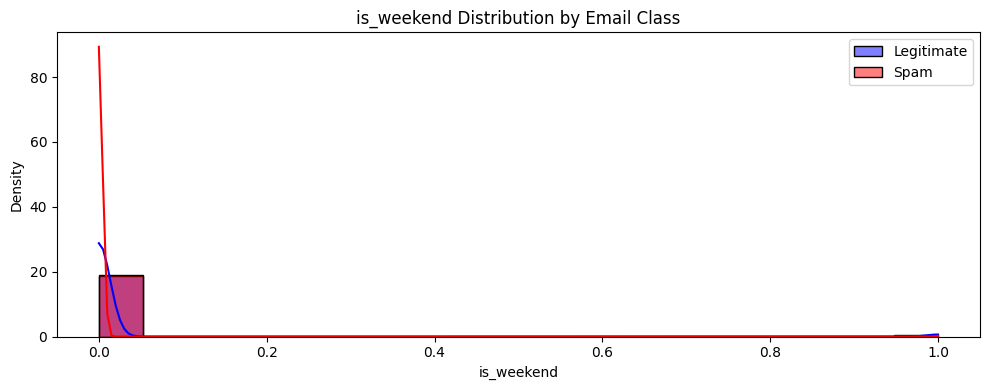

In [142]:
for feature in X_resampled.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(X_resampled[feature][y_resampled == 0], color="blue", label="Legitimate", kde=True, stat="density")
    sns.histplot(X_resampled[feature][y_resampled == 1], color="red", label="Spam", kde=True, stat="density")
    plt.title(f'{feature} Distribution by Email Class')
    plt.legend()
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


lightgbm Model

In [143]:
import lightgbm as lgb
model = lgb.LGBMClassifier().fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 950, number of negative: 146309
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036981 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1074
[LightGBM] [Info] Number of data points in the train set: 147259, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.006451 -> initscore=-5.037014
[LightGBM] [Info] Start training from score -5.037014
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [144]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9996


<Figure size 1000x600 with 0 Axes>

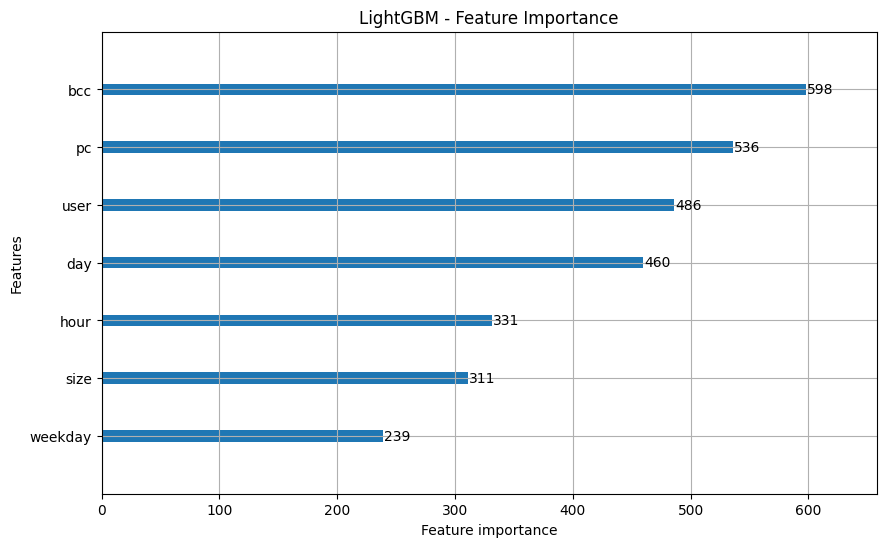

In [145]:
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=10, importance_type='split', figsize=(10, 6))
plt.title('LightGBM - Feature Importance')
plt.show()

Shap

 99%|===================| 36527/36815 [00:17<00:00]       

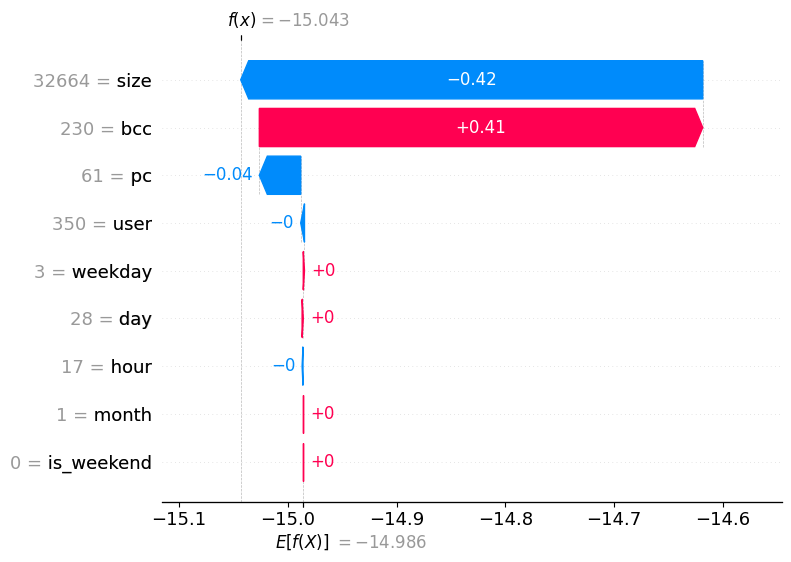

In [146]:
explainer_shap = shap.Explainer(model, X_train)
shap_values = explainer_shap(X_test)
shap.plots.waterfall(shap_values[0])

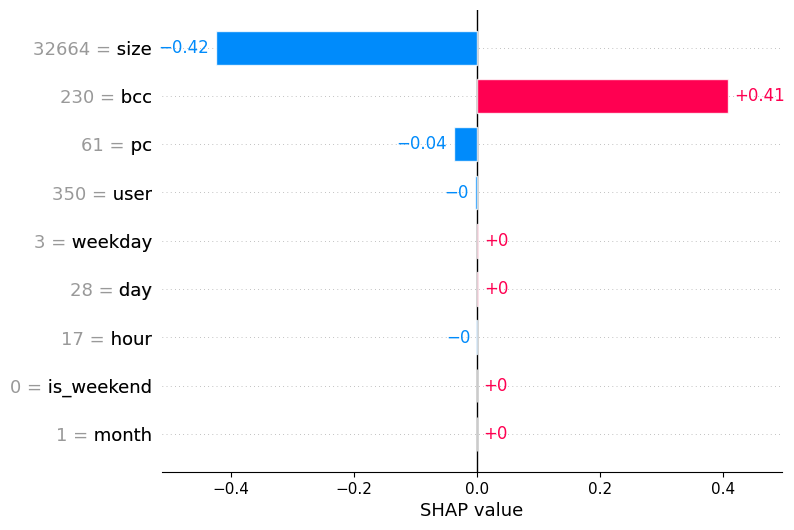

In [147]:
shap.plots.bar(shap_values[0])

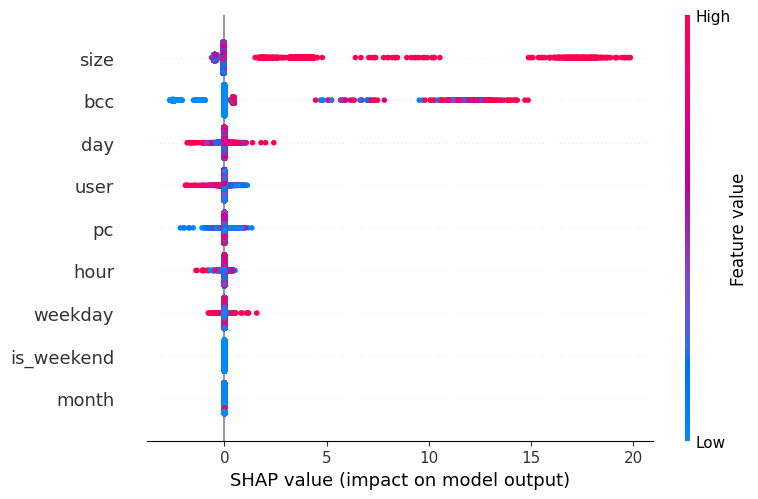

In [148]:
shap.summary_plot(shap_values, X_test)

The plots illustrate the influence of each feature on the prediction made by the model. The baseline prediction is around -14.977. Features such as "size" decrease the prediction somewhat, and "pc" has a slightly positive effect. All other features, such as "user" and "attachments," have virtually no effect. The first plot orders "size" as the most influential feature, followed by "bcc" and "day.". Overall, the model relies to a large extent on a very limited number of important features and the majority of them do not contribute significantly. This allows us to understand more intuitively what is compelling the model towards its decisions.


permutation_importance

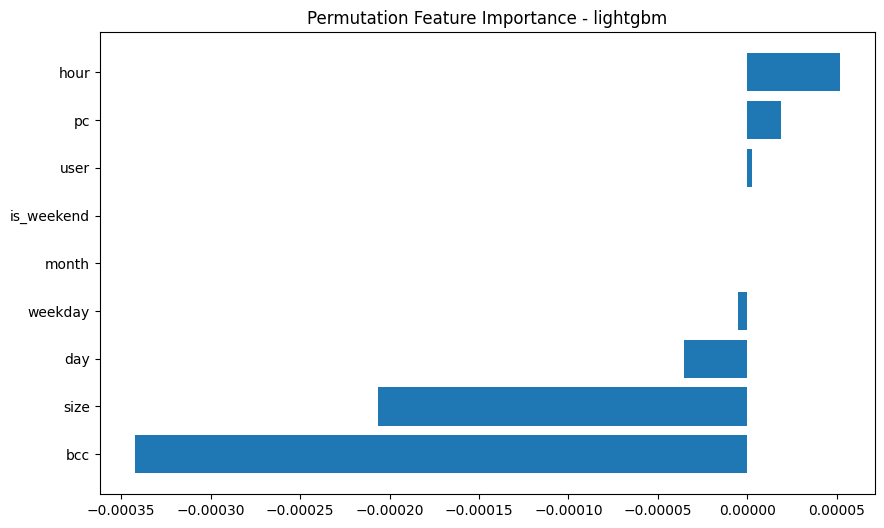

In [149]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

y_pred_test = model.predict(X_test)
y_pred_test = [1 if val == -1 else 0 for val in y_pred_test]

perm_result = permutation_importance(
    model,
    X_test,
    y_pred_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

sorted_idx = perm_result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx], perm_result.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance - lightgbm")
plt.show()

This graph indicates the amount each of the features plays a role in the performance of the model when their values are randomly permuted. "bcc" and "size" play the largest role in the model's performance when altered, whereas features such as "is_weekend" and "month" have minimal or no effect. This again validates that "bcc" and "size" are the most dominant features in the model, whereas others are significantly less. The results are in agreement with the earlier SHAP results above, which verify what characteristics are the driving force behind predictions.

LIME

In [150]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['Benign', 'Threat'],
    mode='classification'
)

def predict_proba_for_lime(X):
    return model.predict_proba(X)

i = 31
exp = explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=predict_proba_for_lime  #
)

exp.show_in_notebook()

The model is 100% confident that the input provided is benign, with no indication of being a threat. The decision is mostly influenced by feature size (32,540) and Dec (0.00), which contributed most to the result. The other features, weekday(2.00), day (6.00), and pc (707.00), had little influence, while is_weekend, attachments, and month had little influence as well. These findings are consistent with previous analyses, echoing that size and Dec are the most influential predictors in the decision of the model, while the remaining features contribute minimally. Having such consistency with various measures of evaluation is an indicator of how strong the model's important predictors are.

LOFO

In [151]:
baseline = cross_val_score(model, X_train, y_train, cv=5).mean()
lofo_scores = {}

for col in X_train.columns:
    X_lofo = X_train.drop(columns=[col])
    score = cross_val_score(model, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score

lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)

[LightGBM] [Info] Number of positive: 760, number of negative: 117047
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1076
[LightGBM] [Info] Number of data points in the train set: 117807, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.006451 -> initscore=-5.037012
[LightGBM] [Info] Start training from score -5.037012
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

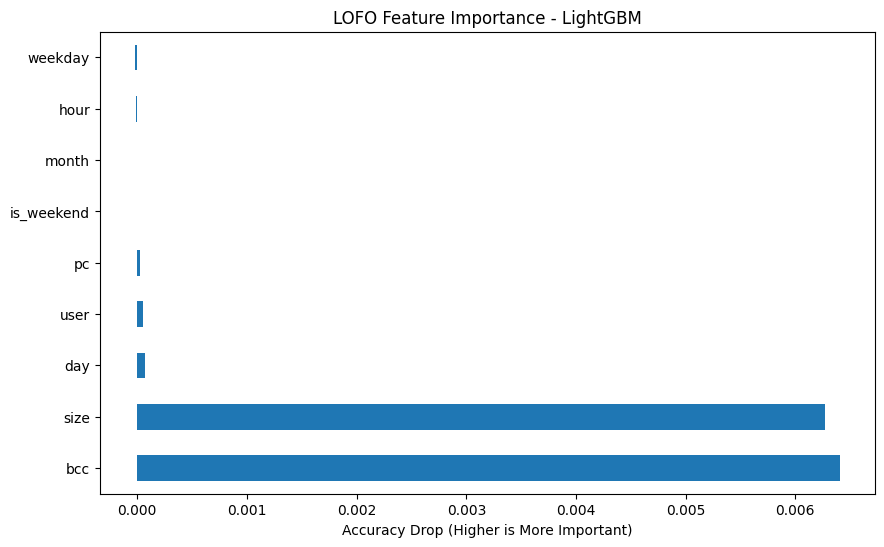

In [152]:
lofo_df.plot(kind='barh', figsize=(10, 6))
plt.title("LOFO Feature Importance - LightGBM")
plt.xlabel("Accuracy Drop (Higher is More Important)")
plt.show()

This graph plots by how much the accuracy of the model drops when one of the features is dropped. "bcc" and "size" produce the largest decrease in performance, so they are most significant in making predictions. Features such as "hour" and "is_weekend" have little impact when dropped, so they play a negligible role. The findings validate the previous analyses, echoing that "bcc" and "size" are the main determinants of the model's decisions, with ancillary roles for the remaining features. This serves to guide the selection of the most valuable variables.